# En Code: les auto-encodeurs - Adaptation pour Faceswap

## Modifications apportées pour passer de MNIST à des visages (Faceswap)

Ce notebook a été adapté pour entraîner un auto-encodeur sur des visages au lieu de chiffres MNIST. Voici les principales modifications :

### 1. Dataset
- **Avant** : MNIST (28x28, niveaux de gris, chiffres manuscrits)
- **Après** : CelebA - vrais visages de célébrités en RGB
- Téléchargement automatique via torchvision.datasets.CelebA
- Dossier créé : `./data/faces/`

### 2. Architecture du modèle
- **input_channels** : 1 → 3 (RGB)
- **input_size** : 28 → 128 (pour commencer avec des images plus petites)
- **latent_dim** : 7 → 512 (pour capturer plus de détails faciaux)
- **hidden_channels** : [32, 64, 128] → [32, 64, 128, 256] (plus de profondeur)
- **output_activation** : Sigmoid → Tanh (meilleur pour [-1,1] après normalisation)

### 3. Entraînement
- **batch_size** : 512 → 16 (images plus grandes, mémoire limitée)
- Ajout de prints périodiques pour suivre la progression

### 4. Faceswap
- Nouvelle section ajoutée pour tester le swap entre deux visages
- Chargement d'images individuelles et échange des représentations latentes

**Note** : L'entraînement prendra plus de temps. Commencez avec 128x128 pour tester, puis passez à 256x256 si possible.

## Importation des bibliothèques

Dans cette cellule, nous importons toutes les bibliothèques nécessaires pour notre projet d'auto-encodeur:

- **PyTorch**: pour la création et l'entraînement du réseau de neurones (torch, nn, optim)
- **DataLoader**: pour charger et traiter les données par lots
- **torchvision**: pour accéder au dataset MNIST et aux transformations d'images
- **NumPy**: pour les opérations numériques
- **Matplotlib**: pour visualiser les images et les résultats
- **tqdm**: pour afficher une barre de progression pendant l'entraînement
- **IPython.display et ipywidgets**: pour l'affichage interactif dans le notebook


In [4]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook
from IPython.display import display
import ipywidgets as widgets
from PIL import Image  # Ajouté pour charger des images individuelles (faceswap)

## Construire l'auto-encodeur

### Définition de l'encodeur convolutif

Cette cellule définit la classe `ConvEncoder`, qui représente la partie encodeur de notre auto-encodeur. L'encodeur est responsable de compresser l'image d'entrée en une représentation latente de dimension réduite.

Caractéristiques principales:
- Architecture basée sur des couches convolutives (CNN)
- Réduction progressive de la dimension spatiale avec stride=2
- Normalisation par lots (BatchNorm) pour stabiliser l'apprentissage
- Activation LeakyReLU pour introduire de la non-linéarité
- Calcul automatique des dimensions intermédiaires avec un tenseur factice
- Couche finale fully-connected pour projeter vers l'espace latent

Le réseau prend une image en entrée et produit un vecteur latent compact qui capture les caractéristiques essentielles de l'image.


In [10]:

class ConvEncoder(nn.Module):

    def __init__(
            self,
            input_channels=1,  # 1 for grayscale (MNIST), 3 for RGB
            input_size=28,     # Input image size (28 for MNIST)
            hidden_channels=None,  # Number of channels in hidden layers
            latent_dim=10,
    ):
        super(ConvEncoder, self).__init__()

        if hidden_channels is None:
            hidden_channels = [32, 64, 128]
        # end if

        self.input_channels = input_channels
        self.input_size = input_size
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        # Build encoder convolutional layers
        encoder_layers = []
        in_channels = input_channels

        for out_channels in hidden_channels:
            encoder_layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True)
            ])
            in_channels = out_channels
        # end for

        self.encoder_conv = nn.Sequential(*encoder_layers)

        # Create a dummy input to calculate the flattened dimension
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_size, input_size)
            dummy_output = self.encoder_conv(dummy_input)
            _, C, H, W = dummy_output.shape
            flattened_dim = C * H * W
        # end with

        # Fully connected layers for latent space
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, latent_dim)
        )

        # Store dimensions for reshaping in decoder
        self.feature_channels = C
        self.feature_height = H
        self.feature_width = W
    # end __init__

    def forward(self, x):
        # Apply convolutional layers
        x = self.encoder_conv(x)

        # Flatten and project to latent space
        latent = self.encoder_fc(x)

        return latent
    # end forward

# end ConvEncoder


### Fonction utilitaire et définition du décodeur convolutif

Cette cellule contient deux éléments importants:

1. **Fonction `load_class`**: Une fonction utilitaire qui permet de charger dynamiquement une classe à partir de son chemin complet. Elle sera utilisée pour charger la fonction d'activation de sortie du décodeur.

2. **Classe `ConvDecoder`**: Le décodeur de notre auto-encodeur, qui est responsable de reconstruire l'image originale à partir de la représentation latente.

Caractéristiques principales du décodeur:
- Commence par une couche fully-connected pour projeter le vecteur latent vers un tenseur 3D
- Utilise des couches de convolution transposée (ConvTranspose2d) pour augmenter progressivement la résolution
- Structure symétrique à l'encodeur, avec les canaux en ordre inverse
- Fonction d'activation configurable en sortie (par défaut Sigmoid)
- Possibilité de recadrer l'image reconstruite aux dimensions cibles

Le décodeur effectue l'opération inverse de l'encodeur, transformant un vecteur latent compact en une image reconstruite.


In [11]:
def load_class(full_class_path):
    module_name, class_name = full_class_path.rsplit(".", 1)
    module = importlib.import_module(module_name)
    return getattr(module, class_name)
# end load_class


class ConvDecoder(nn.Module):

    def __init__(
            self,
            input_channels=1,  # 1 for grayscale (MNIST), 3 for RGB
            hidden_channels=[32, 64, 128],  # Number of channels in hidden layers
            latent_dim=10,
            feature_channels=128,
            feature_height=4,
            feature_width=4,
            output_activation: str = "torch.nn.Sigmoid",
    ):
        super(ConvDecoder, self).__init__()

        self.input_channels = input_channels
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels
        self.feature_channels = feature_channels
        self.feature_height = feature_height
        self.feature_width = feature_width

        flattened_dim = feature_channels * feature_height * feature_width

        # Fully connected layers from latent space
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, flattened_dim),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Build decoder convolutional layers
        decoder_layers = []
        in_channels = hidden_channels[-1]

        # Reverse the hidden channels for the decoder
        for out_channels in reversed(hidden_channels[:-1]):
            decoder_layers.extend([
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True)
            ])
            in_channels = out_channels
        # end for

        # Final layer to output the reconstructed image
        decoder_layers.extend([
            nn.ConvTranspose2d(in_channels, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
        ])

        # Add output activation
        activation_cls = load_class(output_activation)
        decoder_layers.append(activation_cls())

        self.decoder_conv = nn.Sequential(*decoder_layers)
    # end __init__

    def forward(self, z, target_height=None, target_width=None):
        # Project from latent space and reshape
        batch_size = z.size(0)
        x = self.decoder_fc(z)
        x = x.view(batch_size, self.feature_channels, self.feature_height, self.feature_width)

        # Apply transposed convolutional layers
        reconstruction = self.decoder_conv(x)

        # Crop to match target dimensions if provided
        if target_height is not None and target_width is not None:
            if reconstruction.size(2) != target_height or reconstruction.size(3) != target_width:
                # Calculate cropping boundaries
                h_diff = reconstruction.size(2) - target_height
                w_diff = reconstruction.size(3) - target_width
                
                # Ensure we can crop (output must be larger than target)
                if h_diff >= 0 and w_diff >= 0:
                    h_start = h_diff // 2
                    w_start = w_diff // 2
                    
                    # Crop the reconstruction to match target dimensions
                    reconstruction = reconstruction[:, :, h_start:h_start + target_height, w_start:w_start + target_width]
                # end if
            # end if
        # end if

        return reconstruction
    # end forward

# end ConvDecoder

### Assemblage de l'auto-encodeur complet

Cette cellule définit la classe `ConvAutoEncoder`, qui combine l'encodeur et le décodeur pour former l'architecture complète de l'auto-encodeur. Cette classe sert de point d'entrée principal pour l'utilisation du modèle.

Caractéristiques principales:
- Intègre les classes `ConvEncoder` et `ConvDecoder` définies précédemment
- Gère automatiquement la transmission des paramètres entre l'encodeur et le décodeur
- Mémorise les dimensions de l'image d'entrée pour assurer une reconstruction aux bonnes dimensions
- Fournit des méthodes pratiques pour encoder et décoder séparément
- Retourne à la fois la reconstruction et la représentation latente lors de l'appel forward

Cette architecture permet d'encoder une image en un vecteur latent compact, puis de reconstruire l'image à partir de ce vecteur, tout en maintenant les dimensions originales.


In [12]:
class ConvAutoEncoder(nn.Module):

    def __init__(
            self,
            input_channels=1,  # 1 for grayscale (MNIST), 3 for RGB
            input_size=28,     # Input image size (28 for MNIST)
            hidden_channels=[32, 64, 128],  # Number of channels in hidden layers
            latent_dim=10,
            output_activation: str = "torch.nn.Sigmoid",
    ):
        super(ConvAutoEncoder, self).__init__()

        self.input_channels = input_channels
        self.input_size = input_size
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        # Create the encoder
        self.encoder = ConvEncoder(
            input_channels=input_channels,
            input_size=input_size,
            hidden_channels=hidden_channels,
            latent_dim=latent_dim
        )

        # Create the decoder
        self.decoder = ConvDecoder(
            input_channels=input_channels,
            hidden_channels=hidden_channels,
            latent_dim=latent_dim,
            feature_channels=self.encoder.feature_channels,
            feature_height=self.encoder.feature_height,
            feature_width=self.encoder.feature_width,
            output_activation=output_activation
        )
    # end __init__

    def forward(self, x):
        # Store original input shape for later cropping
        self.original_height = x.size(2)
        self.original_width = x.size(3)
        
        # Encode
        latent = self.encode(x)
        
        # Decode with target dimensions matching the input
        reconstruction = self.decode(latent, target_height=self.original_height, target_width=self.original_width)

        return reconstruction, latent
    # end __forward__

    def encode(self, x):
        return self.encoder(x)
    # end encode

    def decode(self, z, target_height=None, target_width=None):
        # Use stored original dimensions if available and no target dimensions provided
        if target_height is None and hasattr(self, 'original_height'):
            target_height = self.original_height
        # end if
        
        if target_width is None and hasattr(self, 'original_width'):
            target_width = self.original_width
        # end if
        
        return self.decoder(z, target_height=target_height, target_width=target_width)
    # end decode

# end ConvAutoEncoder

## Le dataset CelebA (Visages)

### Configuration du matériel d'exécution

Cette cellule configure l'utilisation du GPU via CUDA si disponible. PyTorch peut exécuter les calculs sur CPU ou GPU, et cette configuration permet de détecter automatiquement si un GPU compatible CUDA est disponible sur le système.

- Si un GPU est disponible, les calculs seront effectués sur celui-ci, ce qui accélère considérablement l'entraînement
- Sinon, les calculs seront effectués sur le CPU

La variable `device` sera utilisée tout au long du notebook pour déplacer les tenseurs et les modèles vers le bon périphérique de calcul.


In [5]:
# CUDA setup
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

### Chargement et préparation des données CelebA

Cette cellule configure et charge le jeu de données CelebA, qui contient des images de vrais visages de célébrités en RGB de taille 128x128 pixels (redimensionnées).

**Modifications** :
- Remplacement de MNIST par CelebA
- Images RGB (3 canaux) au lieu de niveaux de gris
- Taille réduite à 128x128 pour commencer
- batch_size réduit à 16
- Transformations adaptées : redimensionnement, normalisation pour RGB

Étapes principales:
- Définition de la taille des lots (batch_size) à 16 images
- Configuration des transformations : redimensionnement à 128x128, conversion en tenseur, normalisation
- Téléchargement automatique de CelebA
- Création des DataLoaders pour l'entraînement et l'évaluation


In [7]:
# Set batch size
batch_size = 16

# Define the transformation for images
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ============================================================================
# Chargement de CelebA (vrais visages de célébrités)
# ============================================================================
print("Téléchargement de CelebA - vrais visages de célébrités...")
try:
    train_dataset = datasets.CelebA(
        root='./data/faces',
        split='train',
        download=True,
        transform=transform
    )
    test_dataset = datasets.CelebA(
        root='./data/faces',
        split='test',
        download=True,
        transform=transform
    )
    print("✓ CelebA téléchargé avec succès !")
    print(f"   - {len(train_dataset)} images d'entraînement")
    print(f"   - {len(test_dataset)} images de test")
    
    # Limiter à 7000 images pour l'entraînement rapide
    from torch.utils.data import Subset
    import random
    if len(train_dataset) > 7000:
        indices = list(range(len(train_dataset)))
        random.shuffle(indices)
        train_dataset = Subset(train_dataset, indices[:7000])
        print(f"   → Limité à {len(train_dataset)} images d'entraînement")
    if len(test_dataset) > 1000:
        indices_test = list(range(len(test_dataset)))
        random.shuffle(indices_test)
        test_dataset = Subset(test_dataset, indices_test[:1000])
        print(f"   → Limité à {len(test_dataset)} images de test")
except Exception as e:
    print(f"✗ CelebA non disponible : {e}")
    print("\n🔄 ALTERNATIVE : Essai avec LFW (Labeled Faces in the Wild)")
    try:
        train_dataset = datasets.LFWPeople(
            root='./data/faces',
            split='train',
            download=True,
            transform=transform
        )
        test_dataset = datasets.LFWPeople(
            root='./data/faces',
            split='test',
            download=True,
            transform=transform
        )
        print("✓ LFW téléchargé avec succès !")
        print(f"   - {len(train_dataset)} images d'entraînement")
        print(f"   - {len(test_dataset)} images de test")
    except Exception as e2:
        print(f"✗ LFW aussi indisponible : {e2}")
        print("\n🔄 ALTERNATIVE : Utilisez vos propres images de visages")
        print("   1. Créez un dossier ./data/faces/custom/")
        print("   2. Ajoutez 20-50+ photos de visages (.jpg)")
        print("   3. Le code utilisera automatiquement ce dossier")
        print("   4. Téléchargez des images depuis Google Images ou utilisez vos photos")
        raise Exception("Datasets indisponibles. Veuillez utiliser vos propres images de visages.")

# Create data loader for training
kwargs = {'num_workers': 2, 'pin_memory': True} if use_cuda else {}
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Create data loader for testing
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

Téléchargement de CelebA - vrais visages de célébrités...
✗ CelebA non disponible : Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM

but Gdown can't. Please check connections and permissions.

🔄 ALTERNATIVE : Essai avec LFW (Labeled Faces in the Wild)
✗ LFW aussi indisponible : LFW dataset is no longer available for download.Please download the dataset manually and place it in the specified directory

🔄 ALTERNATIVE : Utilisez vos propres images de visages
   1. Créez un dossier ./data/faces/custom/
   2. Ajoutez 20-50+ photos de visages (

Exception: Datasets indisponibles. Veuillez utiliser vos propres images de visages.

### Alternative rapide : Utiliser vos propres images

Si les datasets en ligne ne fonctionnent pas, vous pouvez simplement créer un dossier avec vos propres images JPG ou PNG. C'est la solution la plus simple !

**Étapes:**
1. Créez un dossier `./data/faces/custom/`
2. Ajoutez vos images (.jpg ou .png)
3. Exécutez le code ci-dessous


In [8]:
import os
from torch.utils.data import Dataset
import glob

# Créer le dossier s'il n'existe pas
os.makedirs('./data/faces/custom', exist_ok=True)

class CustomFaceDataset(Dataset):
    """Dataset personnalisé pour charger des images locales"""
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform
        # Chercher récursivement tous les fichiers image
        self.images = glob.glob(os.path.join(image_folder, '**', '*.jpg'), recursive=True) + \
                      glob.glob(os.path.join(image_folder, '**', '*.jpeg'), recursive=True) + \
                      glob.glob(os.path.join(image_folder, '**', '*.png'), recursive=True)
        print(f"✓ {len(self.images)} images trouvées dans {image_folder} (recherche récursive)")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # Retourne (image, dummy_label)

# Charger le dataset personnalisé
try:
    custom_folder = './data/faces/custom/'
    dataset = CustomFaceDataset(custom_folder, transform=transform)
    
    # Limiter à 7000 images pour l'entraînement rapide
    if len(dataset) > 7000:
        from torch.utils.data import Subset
        import random
        indices = list(range(len(dataset)))
        random.shuffle(indices)
        dataset = Subset(dataset, indices[:7000])
        print(f"   → Limité à {len(dataset)} images totales")
    
    if len(dataset) < 2:
        raise Exception(f"⚠️ Seulement {len(dataset)} image(s) trouvée(s). Ajoutez au moins 10-20 images dans {custom_folder}")
    
    # Diviser en train/test (80/20)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    print(f"✓ Dataset personnalisé chargé: {train_size} images d'entraînement, {test_size} images de test")
    use_custom = True
    
except Exception as e:
    print(f"✗ Erreur: {e}")
    print(f"\n📁 INSTRUCTIONS:")
    print(f"   1. Créez un dossier: ./data/faces/custom/")
    print(f"   2. Ajoutez 10-20+ images JPG ou PNG dedans")
    print(f"   3. Réexécutez cette cellule")
    use_custom = False

# Créer les dataloaders
if use_custom:
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )


✓ 202599 images trouvées dans ./data/faces/custom/ (recherche récursive)
   → Limité à 7000 images totales
✓ Dataset personnalisé chargé: 5600 images d'entraînement, 1400 images de test


### Extraction d'échantillons du jeu de données

Cette cellule extrait quelques images du jeu d'entraînement pour les visualiser. Nous sélectionnons les 8 premières images du dataset CelebA pour avoir un aperçu des données sur lesquelles nous allons entraîner notre auto-encodeur.

Chaque élément du dataset CelebA est un tuple contenant:
- L'image du visage (un tenseur RGB)
- Les attributs (non utilisés ici)


In [28]:
# Get images from the dataset
n_samples = 8
train_images = list()
for i in range(n_samples):
    train_images.append(train_dataset[i])
# end for

### Visualisation des échantillons CelebA

Cette cellule crée une visualisation des 8 images extraites précédemment. Nous affichons les images RGB dans une grille horizontale.

Le code:
- Crée une figure avec 8 sous-graphiques (subplots) alignés horizontalement
- Pour chaque image, affiche le tenseur RGB (dénormalisé pour l'affichage)
- Désactive les axes pour une meilleure lisibilité
- Ajuste la mise en page et affiche la figure

Cette visualisation nous permet de vérifier visuellement les données d'entrée avant de commencer l'entraînement.


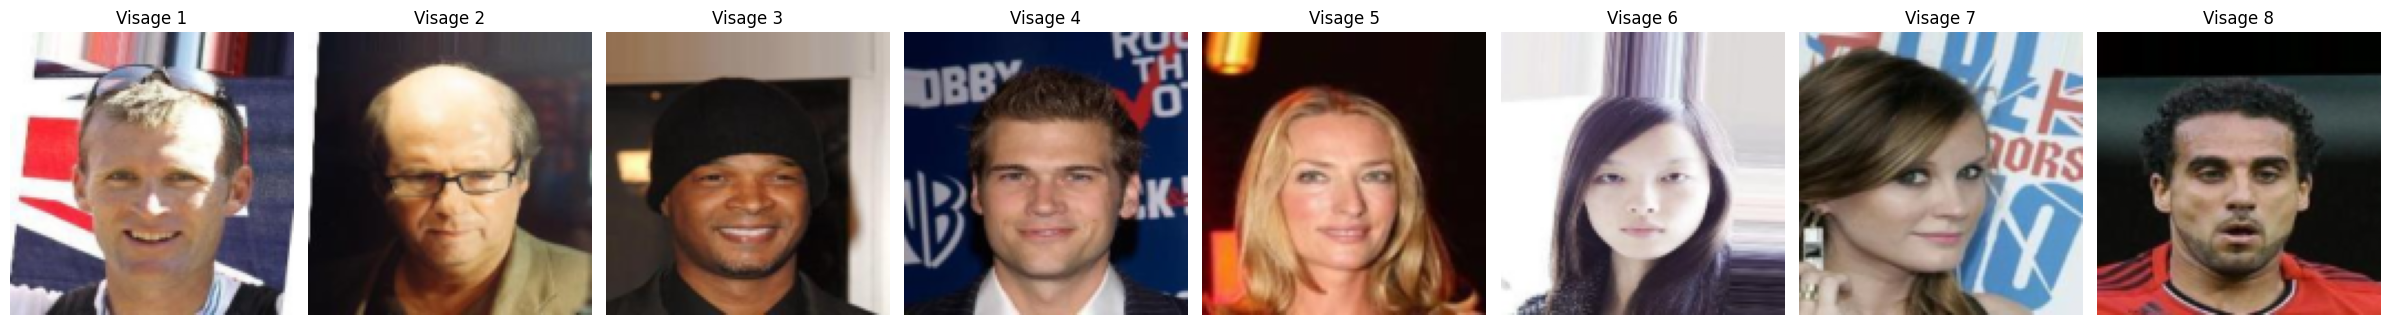

In [29]:
n_samples = 8
fig, axes = plt.subplots(1, n_samples, figsize=(n_samples*3, 6))  # Plus grand pour mieux voir
for ax, (img, _) in zip(axes, train_images):  # Unpack le tuple (image, label)
    # Dénormaliser pour l'affichage : img = (img * std) + mean
    img_display = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5  # Dénormalisation RGB
    # S'assurer que les valeurs sont dans [0,1]
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(f"Visage {list(axes).index(ax)+1}")
    ax.axis('off')
# end for
plt.tight_layout()
plt.show()

## Entraînement

### Fixation des seeds

Cette cellule définit des graines (seeds) fixes pour les générateurs de nombres aléatoires de PyTorch et NumPy. Cette étape est cruciale pour assurer la reproductibilité des résultats.

En fixant ces graines:
- Les initialisations des poids du réseau seront identiques à chaque exécution
- La sélection des mini-lots pendant l'entraînement suivra le même ordre
- Tout comportement aléatoire sera prévisible et reproductible

La valeur 42 est choisie arbitrairement (et est un clin d'œil à "Le Guide du voyageur galactique" où 42 est la réponse à "la grande question sur la vie, l'univers et le reste").


In [19]:
# Set fixed random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Boucle d'entraînement de l'Auto-Encodeur

Dans cette section, nous allons entraîner notre auto-encodeur sur le dataset CelebA. Voici une explication détaillée du code qui suit:

1. **Initialisation du modèle**: Nous créons un auto-encodeur convolutif avec:
   - 3 canaux d'entrée (images RGB)
   - Taille d'entrée de 128x128 pixels (dimensions des images CelebA redimensionnées)
   - 4 couches cachées avec [32, 64, 128, 256] filtres (plus de profondeur)
   - Un espace latent de dimension 512 (pour capturer plus de détails faciaux)
   - Une fonction d'activation Tanh en sortie pour normaliser les valeurs entre -1 et 1

2. **Configuration de l'entraînement**:
   - Fonction de perte: MSE (Mean Squared Error) - mesure la différence entre l'image originale et sa reconstruction
   - Optimiseur: Adam avec un taux d'apprentissage de 0.001 et une régularisation L2 (weight_decay)
   - 50 époques d'entraînement sur l'ensemble du jeu de données

3. **Boucle d'entraînement**:
   - Pour chaque époque et chaque lot (batch) d'images:
     - Transfert des données vers le GPU si disponible
     - Remise à zéro des gradients
     - Passage avant (forward pass) pour obtenir les reconstructions
     - Aplatissement des tenseurs pour le calcul de la perte
     - Calcul de l'erreur de reconstruction (MSE)
     - Rétropropagation du gradient (backward pass)
     - Mise à jour des poids du réseau
     - Affichage de la progression et de la perte courante

Cette boucle d'entraînement permet au modèle d'apprendre progressivement à encoder les images dans un espace latent compact, puis à les reconstruire avec le maximum de fidélité possible.

### Création du modèle d'auto-encodeur

Cette cellule instancie notre modèle d'auto-encodeur convolutif avec les paramètres suivants:

- `input_channels=3`: Les images CelebA sont en RGB (3 canaux)
- `input_size=128`: Les images CelebA sont redimensionnées à 128x128 pixels
- `hidden_channels=[32, 64, 128, 256]`: Architecture avec 4 couches cachées de complexité croissante
- `latent_dim=512`: L'espace latent a 512 dimensions (plus grand pour les visages)
- `output_activation='torch.nn.Tanh'`: Activation Tanh en sortie pour normaliser les valeurs entre -1 et 1

La méthode `.to(device)` déplace le modèle sur le GPU si disponible, sinon il reste sur le CPU.


In [13]:
model = ConvAutoEncoder(
    input_channels=3,  # CelebA has 3 channels (RGB)
    input_size=128,    # CelebA images resized to 128x128
    hidden_channels=[32, 64, 128, 256],  # Deeper architecture
    latent_dim=512,    # Larger latent space for faces
    output_activation='torch.nn.Tanh',  # Tanh for [-1,1] range
).to(device)

### Affichage de la structure du modèle

Cette cellule affiche un résumé de la structure du modèle d'auto-encodeur que nous venons de créer. En exécutant simplement la variable `model` dans une cellule Jupyter, nous obtenons une représentation textuelle de l'architecture complète.

Cette représentation montre:
- La hiérarchie des modules (ConvAutoEncoder, ConvEncoder, ConvDecoder)
- Les couches qui composent chaque module
- Les paramètres de chaque couche

Cet affichage est utile pour vérifier que le modèle a été correctement configuré avant de commencer l'entraînement.


In [1]:
model

NameError: name 'model' is not defined

### Configuration de la fonction de perte et de l'optimiseur

Cette cellule définit deux éléments essentiels pour l'entraînement du modèle:

1. **Fonction de perte (Loss function)**: Nous utilisons l'erreur quadratique moyenne (MSE - Mean Squared Error) qui mesure la différence pixel par pixel entre l'image originale et sa reconstruction. Cette métrique est bien adaptée pour les auto-encodeurs car elle encourage le modèle à reconstruire des images visuellement similaires aux originales.

2. **Optimiseur**: Nous utilisons Adam, un algorithme d'optimisation populaire qui adapte automatiquement les taux d'apprentissage pour chaque paramètre avec:
   - `lr=0.001`: Taux d'apprentissage initial
   - `weight_decay=0.0004`: Régularisation L2 qui aide à prévenir le surapprentissage en pénalisant les grands poids

L'optimiseur Adam combine les avantages de plusieurs techniques d'optimisation et converge généralement plus rapidement que la descente de gradient stochastique classique.


In [14]:
# Define loss function and optimizer
criterion = torch.nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0004
)

In [15]:
epochs = 60
total_steps = epochs * len(train_loader)
pbar = tqdm.notebook.tqdm(total=total_steps, desc="Entraînement", leave=True)

for epoch in range(1, epochs + 1):
    model.train()
    # Iterate through training
    for data_i, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        recon_batch, _ = model(data)
        
        # Flatten the input if it's not already flattened
        if len(data.shape) > 2:
            data = data.view(data.size(0), -1)
        # end if
        
        # Flatten the output if it's not already flattened
        if len(recon_batch.shape) > 2:
            recon_batch = recon_batch.reshape(recon_batch.size(0), -1)
        # end if

        # Calculate loss
        loss = criterion(recon_batch, data)
        
        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Show loss
        pbar.set_postfix(loss=loss.item())
        pbar.update(1)
        
        # Afficher la progression toutes les 100 étapes
        if (data_i + 1) % 100 == 0:
            print(f"Époque {epoch}/{epochs}, Étape {data_i + 1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    # end for data
    print(f"Époque {epoch}/{epochs} terminée, Loss moyenne: {loss.item():.6f}")
# end for epoch
model.eval()

Entraînement:   0%|          | 0/21000 [00:00<?, ?it/s]

Époque 1/60, Étape 100/350, Loss: 0.152906
Époque 1/60, Étape 200/350, Loss: 0.113067
Époque 1/60, Étape 300/350, Loss: 0.093365
Époque 1/60 terminée, Loss moyenne: 0.114673
Époque 2/60, Étape 100/350, Loss: 0.100928
Époque 2/60, Étape 200/350, Loss: 0.093137
Époque 2/60, Étape 300/350, Loss: 0.098703
Époque 2/60 terminée, Loss moyenne: 0.117353
Époque 3/60, Étape 100/350, Loss: 0.081096
Époque 3/60, Étape 200/350, Loss: 0.085640
Époque 3/60, Étape 300/350, Loss: 0.089197
Époque 3/60 terminée, Loss moyenne: 0.077154
Époque 4/60, Étape 100/350, Loss: 0.093544
Époque 4/60, Étape 200/350, Loss: 0.066682
Époque 4/60, Étape 300/350, Loss: 0.088483
Époque 4/60 terminée, Loss moyenne: 0.083595
Époque 5/60, Étape 100/350, Loss: 0.075541
Époque 5/60, Étape 200/350, Loss: 0.082606
Époque 5/60, Étape 300/350, Loss: 0.069750
Époque 5/60 terminée, Loss moyenne: 0.064204
Époque 6/60, Étape 100/350, Loss: 0.071638
Époque 6/60, Étape 200/350, Loss: 0.077147
Époque 6/60, Étape 300/350, Loss: 0.065363
É

ConvAutoEncoder(
  (encoder): ConvEncoder(
    (encoder_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (encoder_fc): Seq

In [2]:
# Sauvegarder le modèle entraîné
torch.save(model.state_dict(), 'autoencoder_trained.pth')
print("✓ Modèle sauvegardé : autoencoder_trained.pth")

NameError: name 'torch' is not defined

## Reconstruction

### Chargement des données de test

Après avoir entraîné notre modèle, nous allons maintenant l'évaluer sur des données de test qu'il n'a jamais vues pendant l'entraînement. Cette cellule:

1. Extrait un lot (batch) d'images du jeu de test en utilisant `next(iter(test_loader))`
2. Sépare les images (`test_images`) et leurs étiquettes (`test_cls`)
3. Déplace les tenseurs vers le GPU si disponible avec `.to(device)`

Ces images de test seront utilisées pour évaluer visuellement la qualité des reconstructions produites par notre auto-encodeur entraîné.


In [16]:
# Get images from the test dataset
test_data = next(iter(test_loader))
test_images, test_cls = test_data
test_images, test_cls = test_images.to(device), test_cls.to(device)

## Génération des reconstructions

Cette cellule fait passer les images de test à travers notre auto-encodeur entraîné. Le modèle effectue deux opérations:

1. **Encodage**: Compression des images en vecteurs latents de dimension 7
2. **Décodage**: Reconstruction des images à partir de ces vecteurs latents

La fonction `model(test_images)` retourne deux éléments:
- `test_recon`: Les images reconstruites (qui devraient ressembler aux images originales)
- `test_latent`: Les représentations latentes des images (vecteurs de dimension 7)

Ces résultats nous permettront d'évaluer visuellement la qualité de reconstruction et d'explorer l'espace latent.


In [17]:
# Passe dans l'auto-encodeur
test_recon, test_latent = model(test_images)

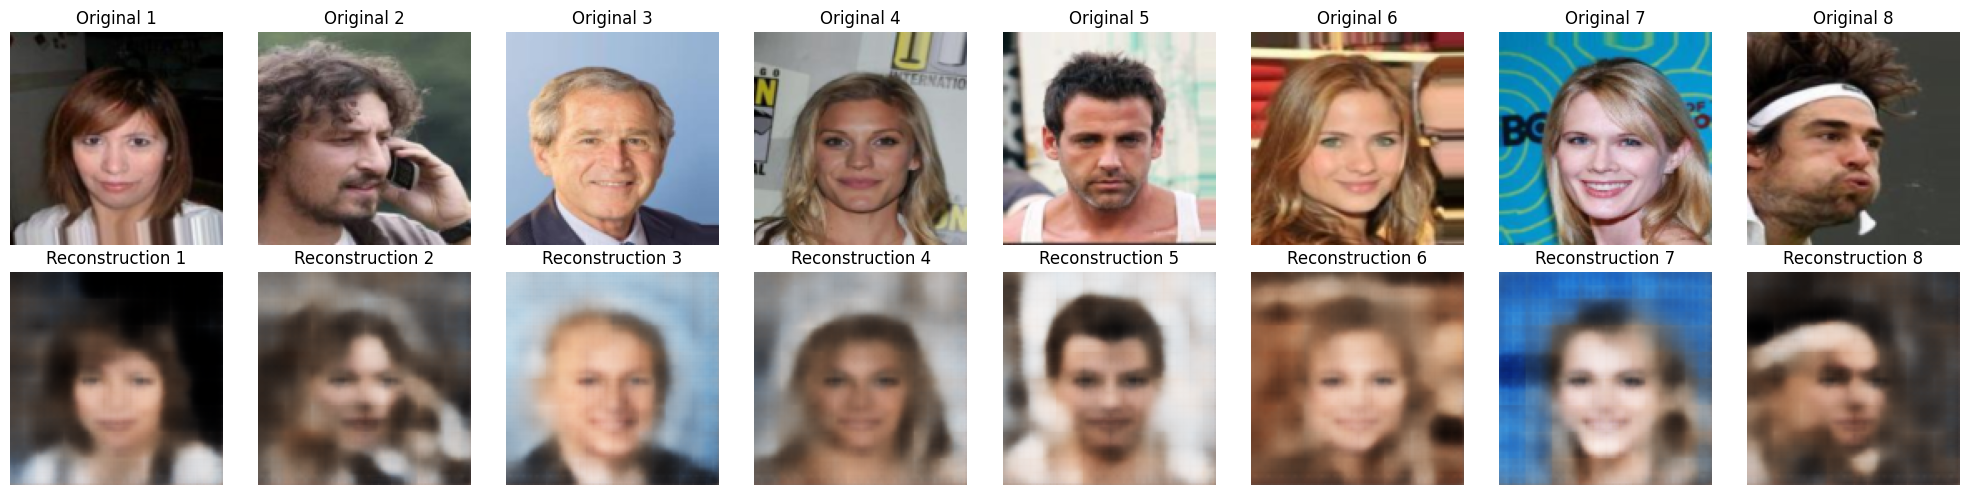

In [18]:
n_samples = 8
fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2.5, 5))
# Row
for ax_i, ax in enumerate(axes):
    # Column
    for ax_j, ay in enumerate(ax):
        if ax_i == 0:
            # Afficher l'image originale RGB avec dénormalisation
            img_display = test_images[ax_j].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            ay.imshow(img_display)
            ay.set_title(f"Original {ax_j+1}")
        else:
            # Afficher la reconstruction RGB avec dénormalisation
            img_display = test_recon[ax_j].detach().cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            ay.imshow(img_display)
            ay.set_title(f"Reconstruction {ax_j+1}")

        # end if
        ay.axis('off')
    # end for
# end for
plt.tight_layout()
plt.show()

## Visualiser le latent avec T-SNE

Cette section utilise l'algorithme T-SNE (t-Distributed Stochastic Neighbor Embedding) pour visualiser l'espace latent de notre auto-encodeur en deux dimensions. T-SNE est une technique de réduction de dimensionnalité particulièrement adaptée à la visualisation de données de haute dimension.

Le processus se déroule en plusieurs étapes:

1. **Extraction des représentations latentes**: Nous passons toutes les images du jeu de test dans l'encodeur pour obtenir leurs représentations latentes (vecteurs de dimension 7).

2. **Préparation des données**: Les vecteurs latents et les étiquettes correspondantes (chiffres de 0 à 9) sont collectés et convertis en tableaux NumPy.

3. **Application de T-SNE**: L'algorithme T-SNE réduit les vecteurs latents de dimension 7 à seulement 2 dimensions, tout en préservant au maximum les relations de proximité entre les points.

4. **Visualisation**: Les points 2D sont affichés dans un graphique de dispersion, avec une couleur différente pour chaque chiffre (0-9).

Cette visualisation nous permet d'observer comment l'auto-encodeur organise les différents chiffres dans son espace latent. Si l'entraînement a bien fonctionné, nous devrions voir des clusters distincts pour chaque chiffre, ce qui indique que l'encodeur a appris à séparer les différentes classes dans l'espace latent, même sans supervision explicite.


Cette section utilise l'algorithme T-SNE (t-Distributed Stochastic Neighbor Embedding) pour visualiser l'espace latent de notre auto-encodeur en deux dimensions. T-SNE est une technique de réduction de dimensionnalité particulièrement adaptée à la visualisation de données de haute dimension.

Le processus se déroule en plusieurs étapes:

1. **Extraction des représentations latentes**: Nous passons toutes les images du jeu de test dans l'encodeur pour obtenir leurs représentations latentes (vecteurs de dimension 7).

2. **Préparation des données**: Les vecteurs latents et les étiquettes correspondantes (chiffres de 0 à 9) sont collectés et convertis en tableaux NumPy.

3. **Application de T-SNE**: L'algorithme T-SNE réduit les vecteurs latents de dimension 7 à seulement 2 dimensions, tout en préservant au maximum les relations de proximité entre les points.

4. **Visualisation**: Les points 2D sont affichés dans un graphique de dispersion, avec une couleur différente pour chaque chiffre (0-9).

Cette visualisation nous permet d'observer comment l'auto-encodeur organise les différents chiffres dans son espace latent. Si l'entraînement a bien fonctionné, nous devrions voir des clusters distincts pour chaque chiffre, ce qui indique que l'encodeur a appris à séparer les différentes classes dans l'espace latent, même sans supervision explicite.


### Remarques supplémentaires sur T-SNE

T-SNE est particulièrement utile pour visualiser des données de haute dimension car il préserve les structures locales. Contrairement à d'autres techniques comme PCA (Analyse en Composantes Principales), T-SNE se concentre sur la préservation des distances entre points voisins plutôt que sur la variance globale des données.

Points importants à noter sur T-SNE:

1. **Perplexité**: Ce paramètre contrôle l'équilibre entre la préservation des structures locales et globales. Des valeurs typiques sont entre 5 et 50.

2. **Nature stochastique**: T-SNE utilise une initialisation aléatoire, donc chaque exécution peut produire des visualisations légèrement différentes.

3. **Interprétation**: Dans la visualisation T-SNE, les distances absolues entre clusters éloignés ne sont pas significatives. Seule la présence de clusters distincts est interprétable.

4. **Temps de calcul**: Pour de grands ensembles de données, T-SNE peut être coûteux en calcul. Des alternatives comme UMAP peuvent être considérées.

Dans notre cas, T-SNE nous aide à vérifier si notre auto-encodeur a appris des représentations latentes significatives, où des chiffres similaires sont regroupés ensemble dans l'espace latent.

In [40]:
# On récupère tous les latents du jeu de test
latents = list()
digits = list()
for data_i, (data, cls) in enumerate(test_loader):
    data = data.to(device)
    
    # Forward pass
    _, latent = model(data)

    # Add batch
    latents.append(latent)
    digits.append(cls)
# end for

# Concat all
latents = torch.cat(latents, dim=0).cpu()
digits = torch.cat(digits, dim=0).cpu()

In [18]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 11.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.6 MB 11.2 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/36.6 MB 11.4 MB/s eta 0:00:03
   -------- ------------------------------- 7.3/36.6 MB 11.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/36.6 MB 11.6 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/36.6 MB 11.7 MB/s eta 0:00:03
   ---------------- ----------------------- 14.7/36.6 MB 11.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/36.6 MB 11.6 MB/s eta 0:00:02
   -


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from sklearn.manifold import TSNE

# Convert latents to numpy for t-SNE
latents_np = latents.detach().cpu().numpy()

# Apply t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42)
latents_2d = tsne.fit_transform(latents_np)

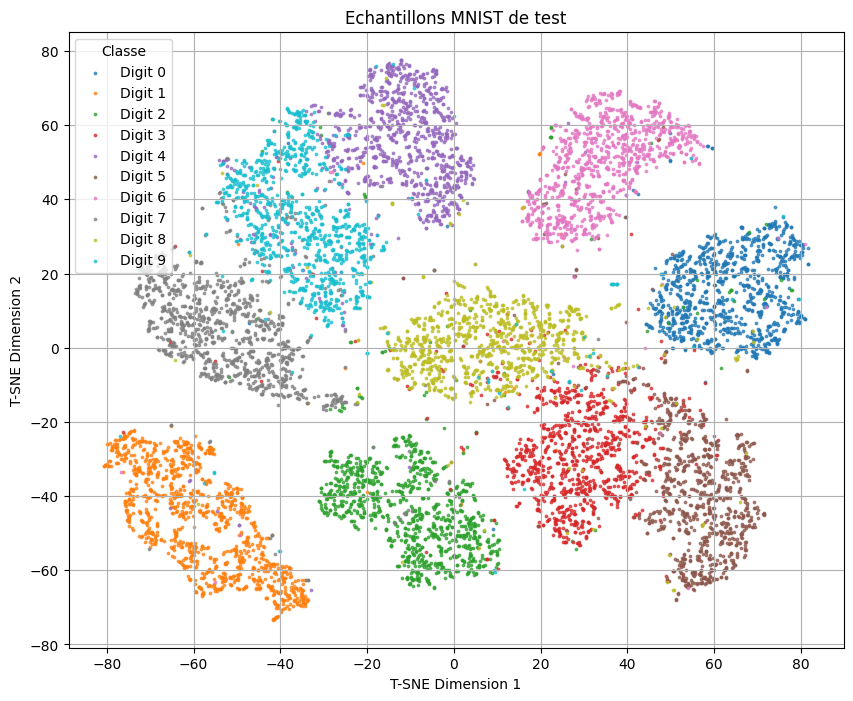

In [20]:
from matplotlib.cm import get_cmap

# Mapping des classes vers des noms
class_names = {idx:f"Digit {idx}" for idx in digits.unique().tolist()}

# Colormap discrète
cmap = plt.get_cmap('tab10')  # jusqu'à 10 classes distinctes
colors = [cmap(i) for i in range(len(class_names))]

plt.figure(figsize=(10, 8))
# plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=digits.numpy(), s=2, alpha=0.6)

# Boucle sur les classes pour tracer chaque groupe
for class_id, class_label in class_names.items():
    idx = digits == class_id
    plt.scatter(
        latents_2d[idx, 0], 
        latents_2d[idx, 1], 
        color=colors[class_id],
        label=class_label,
        alpha=0.7, 
        s=3
    )
# end for

plt.legend(title="Classe")
plt.xlabel("T-SNE Dimension 1")
plt.ylabel("T-SNE Dimension 2")
plt.title("Echantillons MNIST de test")
plt.grid(True)
plt.show()

## Faceswap

Cette section démontre l'application principale : l'échange de visages (faceswap) en utilisant l'auto-encodeur entraîné.

### Concept du Faceswap avec Auto-Encodeur

Pour effectuer un faceswap basique :
1. Charger deux images de visages (A et B)
2. Encoder chaque visage pour obtenir leurs représentations latentes
3. Échanger les latents : décoder latent de A avec le décodeur → visage B avec caractéristiques de A
4. Afficher les résultats

**Note** : Cette implémentation est simplifiée. Pour de meilleurs résultats, on utiliserait des architectures plus avancées comme des VAEs ou des GANs.

### Implémentation du Faceswap

Dans le code suivant, nous chargeons deux images de visages et effectuons l'échange.

### Implémentation du Morphing

Dans le code qui suit, nous allons mettre en pratique le concept de morphing expliqué ci-dessus. Voici les étapes détaillées de l'implémentation:

1. **Sélection aléatoire**: Nous choisissons deux échantillons aléatoires de notre jeu de test, identifiés par `id1` et `id2`. Pour chacun, nous récupérons sa représentation latente (`lat1`, `lat2`) et son chiffre correspondant (`dig1`, `dig2`).

2. **Création des points intermédiaires**: Nous définissons `morphing_size = 10` pour créer 10 points intermédiaires. Nous utilisons `torch.linspace(0, 1, steps=morphing_size)` pour générer une séquence de valeurs t allant de 0 à 1, puis nous calculons l'interpolation linéaire avec la formule:
   ```
   interpolations = (1 - t_values) * lat1 + t_values * lat2
   ```

3. **Décodage et visualisation**: Pour chaque point intermédiaire, nous utilisons le décodeur du modèle pour générer l'image correspondante. Nous affichons ensuite toutes ces images côte à côte, montrant la transition progressive d'un chiffre à l'autre.

Cette implémentation nous permet de visualiser concrètement comment l'auto-encodeur a appris un espace latent continu où l'interpolation entre deux points produit des transitions visuellement cohérentes.


In [21]:
# Prend deux représentations latentes dans le jeu de test
id1 = np.random.randint(latents.size(0)) + 2
id2 = np.random.randint(latents.size(0)) + 2
lat1, dig1 = latents[id1], digits[id1]
lat2, dig2 = latents[id2], digits[id2]

In [22]:
# Calcule l'interpolation linéaire des latents
morphing_size = 10
t_values = torch.linspace(0, 1, steps=morphing_size).unsqueeze(1)
interpolations = (1 - t_values) * lat1 + t_values * lat2

In [23]:
# Calcule les reconstructions pour chaque latents
lat_rec = list()
for r_i in range(morphing_size):
    lat = interpolations[r_i].to(device).unsqueeze(0)
    rec = model.decode(lat)
    lat_rec.append(rec[0])
# end for
morph_rec = torch.cat(lat_rec, dim=0)

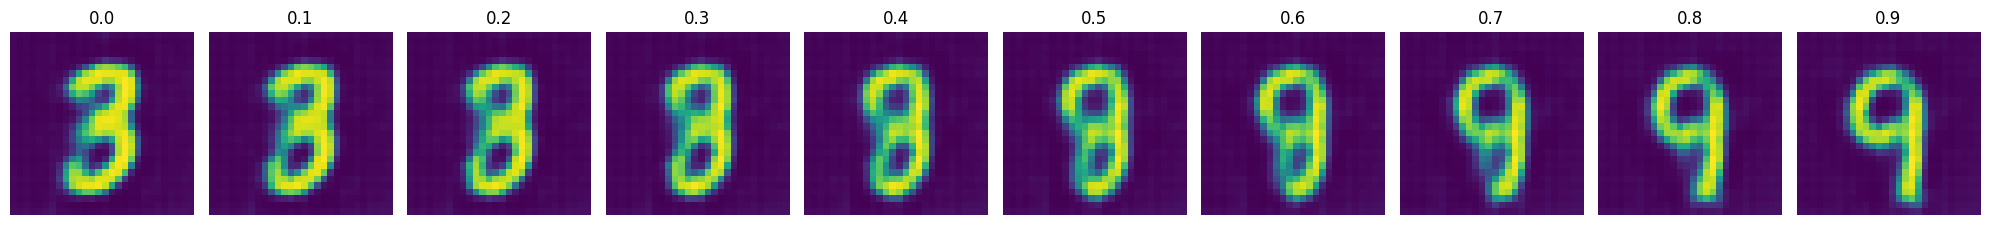

In [24]:
fig, axes = plt.subplots(1, morphing_size, figsize=(morphing_size*2, 4))
for ax_i, ax in enumerate(axes):
    # Dénormaliser pour l'affichage
    img_display = morph_rec[ax_i].detach().cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img_display)
    ax.set_title(f"t={ax_i/(morphing_size-1):.1f}")
    ax.axis('off')
# end for
plt.tight_layout()
plt.show()